# Protocol and Validity

**ANALYSIS notebook — the corpus, the two feedback protocols, judge calibration, and the offline proxy**

This is an **analysis** notebook: it characterizes the data and results and makes no method claims.

Every section follows *Question → What we do → Figure/Table → Reading → Artifact → Caveat*.
Each code cell states what it does and each output is interpreted in the following
cell, so a reader with no access to the code can follow the reasoning. All numbers are
read from immutable artifacts in `results/` through `paper_lib`; missing optional
experiments print `PENDING` with their producer command instead of failing.

In [13]:
import warnings
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display, Markdown
import paper_lib as L

warnings.filterwarnings("ignore", category=FutureWarning)
pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 130)
pd.set_option("display.width", 200)
np.random.seed(42)

PRIMARY_RUN = "M4_intersection_dev_conditioned_continuous"
BLIND_RUN = "M4_intersection_dev_blind_continuous"
GATE_FEATURE_COLS = ["top1_faiss", "top5_mean_faiss", "top5_min_faiss", "top5_std_faiss",
                     "retrieval_margin", "top5_spread", "retrieval_overlap", "max_lift",
                     "mean_lift", "n_positive_lifts", "n_negative_lifts", "lift_conflict",
                     "evidence_density", "query_desc_len", "query_title_len"]
print("Project root:", L.ROOT)

Project root: C:\Users\ailab\Documents\code\financial-pilot-ea\paper_ieee_access


### What evidence exists and how was it produced?

**What we do.** List every artifact the paper relies on and the latest run that produced it (smoke runs and superseded re-runs excluded).

**Artifact.** `results/registry.csv`

**Caveat.** Availability is not quality; the rest of the notebook assesses validity.

*What this cell does.* Print an availability table (which experiments have run) and a provenance table (latest run per script).

In [14]:
display(L.artifact_status())
display(L.provenance_table())

,section,available,path,producer
0,Validity: proxy,True,results\proxy_validation\report.json,07_validate_proxy.py
1,Validity: calibration,True,results\feedback_calibration\report.json,10_feedback_calibration.py
2,Validity: rescoring,True,results\rescored\method_comparison_v2.csv,08_rescore.py
3,Granularity: ladder,True,results\retriever_ladder\grid.csv,11_retriever_ladder.py
4,Granularity: blind ladder,True,results\retriever_ladder_blind\grid.csv,11_retriever_ladder.py --feedback-protocol blind --tag blind
5,Granularity: blend,True,results\blend_eb\dev_eval.csv,12_learn_blend.py --lift laplace_eb --tag eb
6,Granularity: blind blend,True,results\blend_eb_blind\dev_eval.csv,12_learn_blend.py --lift laplace_eb --feedback-protocol blind --tag eb_blind
7,Gate pilot: blind,True,results\gate_pilot_blind\gate_pilot.csv,16_gate_pilot.py --feedback-protocol blind --tag blind
8,Volume,True,results\feedback_volume\summary.csv,13_feedback_volume_curve.py
9,Held-out ladder,False,results\retriever_ladder_eval\grid.csv,11_retriever_ladder.py --split eval --tag eval


,run_id,phase,script,headline_metric,headline_value,git_sha,git_dirty
0,gate_pilot_20260920_214436,P5-gate-pilot,16_gate_pilot.py,max_oof_auc,0.658246,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
1,rescore_20260920_181006,P1.2-rescore,08_rescore.py,n_runs,7.000000,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
2,M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_seed456_20260920_180230,P4-generation,04_evaluate.py,mean_delta_cosine,-0.000850,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
3,M5_backoff_dev_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_seed123_20260920_180151,P4-generation,04_evaluate.py,mean_delta_cosine,0.004920,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
4,M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_disjoint_20260920_172720,P4-generation,04_evaluate.py,mean_delta_cosine,0.005100,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
5,M4_intersection_eval_blind_continuous_20260920_171109,P4-generation,04_evaluate.py,mean_delta_cosine,-0.038320,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
6,M2_team_eval_blind_continuous_20260920_171109,P4-generation,04_evaluate.py,mean_delta_cosine,-0.038270,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
7,M2_team_eval_conditioned_continuous_20260920_134039,P4-generation,04_evaluate.py,mean_delta_cosine,0.013770,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
8,M4_intersection_eval_conditioned_continuous_20260920_134030,P4-generation,04_evaluate.py,mean_delta_cosine,0.015120,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True
9,M5_backoff_eval_blind_continuous_liftlaplace_eb_pool_std0.5_minev2_20260920_132729,P4-generation,04_evaluate.py,mean_delta_cosine,0.002150,5f14ac60755fa6c553e9f6eb742718fc04f0e6b9,True


**Reading.** The availability table shows the paper's full evidence base: the corrected protocol
runs, calibration, proxy validation, rescoring, the conditioned and blind retriever ladders,
the blend/backoff grids, the volume curves, and the gate pilots. The provenance table ties each
number to a run id, a git commit, and its inputs, so every figure can be reproduced.

### What does the ticket corpus look like, and how is it partitioned?

**What we do.** The corpus has 1,595 IT tickets; splits are train (feedback source) / dev (development) / eval (final test). Composition is audited but the assignment is a seeded random permutation, not stratified.

**Artifact.** `data/processed/dataset.parquet; splits/split_seed42.json`

**Caveat.** One organizational corpus, so cross-domain validity is out of scope.

*What this cell does.* Load the canonical table, map tickets to splits, print split sizes, and plot the largest teams and intent classes.

,n,teams,classes
split,,,
dev,319,29,16
eval,398,31,17
train,878,35,16


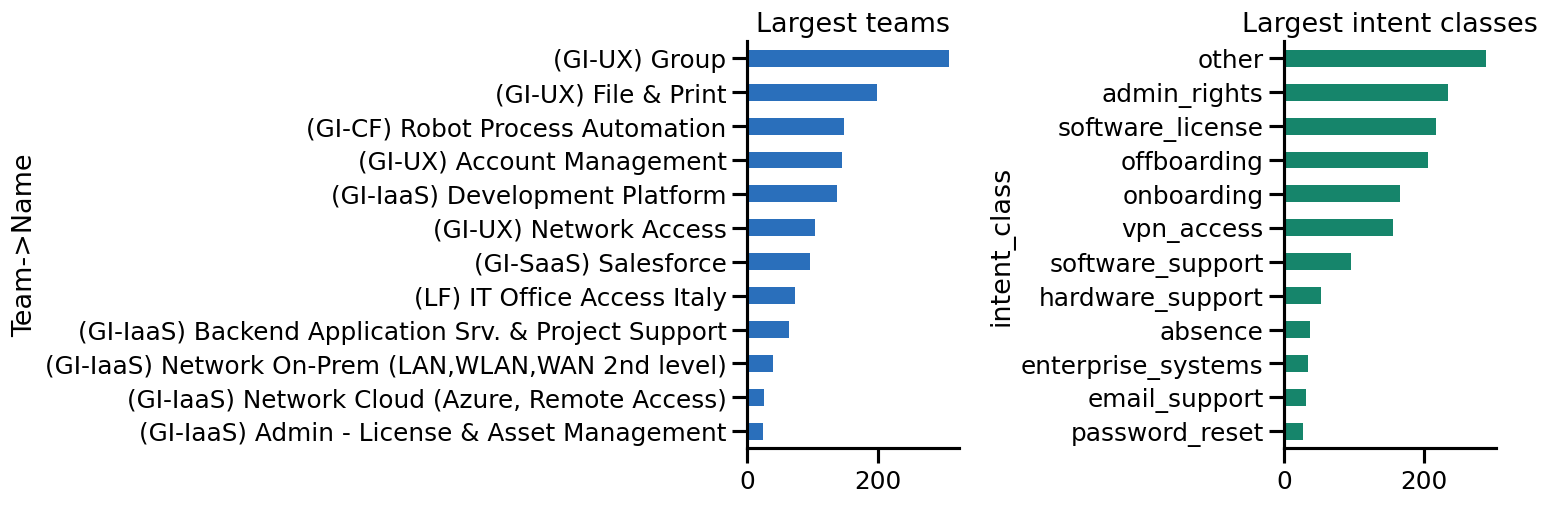

In [15]:
df = L.load_dataset(columns=["seq_id", "intent_class", "Team->Name"])
split = L.load_splits(42)
membership = {qid: part for part in ("train", "dev", "eval") for qid in split[part]}
composition = (df.assign(split=df["seq_id"].map(membership)).dropna(subset=["split"])
               .groupby("split").agg(n=("seq_id", "size"), teams=("Team->Name", "nunique"), classes=("intent_class", "nunique")))
display(composition)
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))
df["Team->Name"].value_counts().head(12).sort_values().plot.barh(ax=axes[0], color="#2a6fbb", title="Largest teams")
df["intent_class"].value_counts().head(12).sort_values().plot.barh(ax=axes[1], color="#16856b", title="Largest intent classes")
plt.tight_layout(); L.savefig("02_corpus_composition", run_ids=[]); plt.show()

**Reading.** The corpus is heavily imbalanced: a handful of teams and a few intent classes dominate,
and many scopes have very few tickets. This matters for the paper because feedback evidence is
aggregated *per scope*, so sparse scopes (small teams, rare intersections) will carry little
evidence — which is exactly the regime the hierarchical backoff is designed for. The eval split
is never used for any decision.

### How is the feedback signal produced?

**What we do.** Two protocols: resolution-informed (conditioned) and ticket-only (blind). We compare their score distributions and their reliability as usefulness rankers.

**Artifact.** `results/feedback_calibration/report.json; reliability_{conditioned,blind}.csv`

**Caveat.** AUC measures ranking, not probability calibration; conditioned is resolution-informed by construction.

*What this cell does.* Print per-protocol summary statistics (mean, zero share, distinct values, AUC, monotonicity), then plot the reliability curves.

,protocol,mean_score,pct_exact_0,n_distinct,auc_same_reply,auc_same_group,monotone_usefulness
0,conditioned,0.2279,0.5875,24,0.9013,0.9472,True
1,blind,0.2521,0.4829,22,0.8361,0.7756,False


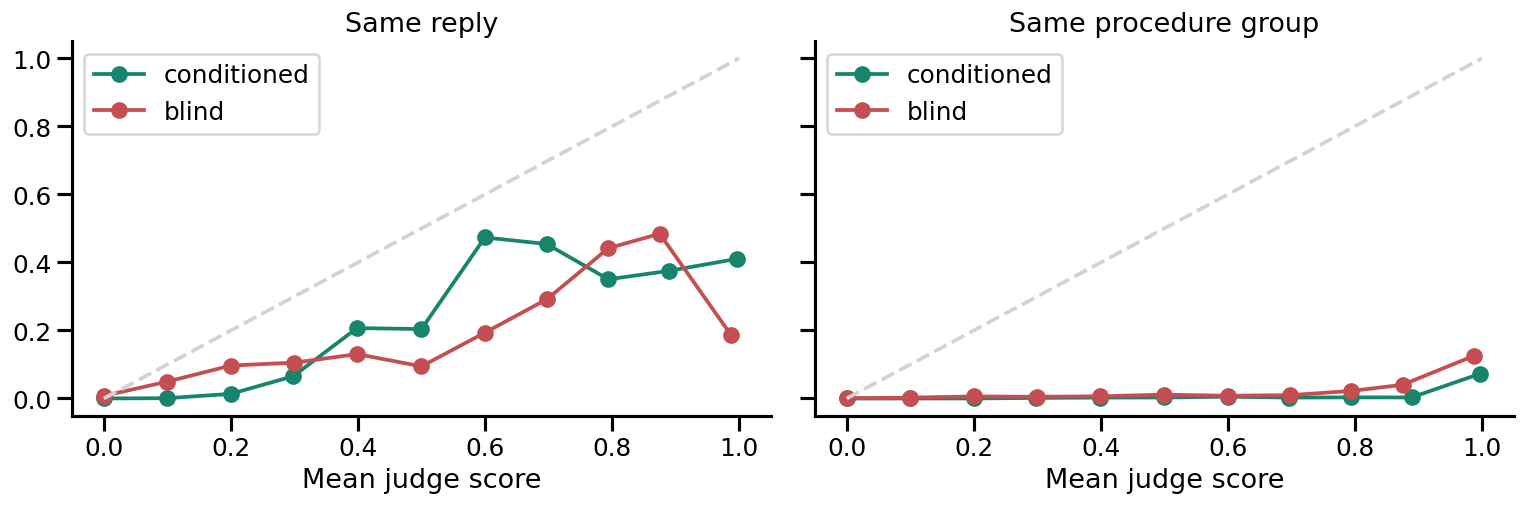

In [16]:
cal = L.load_calib_report()
rows = []
for proto, r in cal["protocols"].items():
    auc = r.get("auc_of_score", {})
    rows.append({"protocol": proto, "mean_score": r["score_distribution"]["mean"],
                 "pct_exact_0": r["score_distribution"]["pct_exact_0"],
                 "n_distinct": r["score_distribution"]["n_distinct_scores"],
                 "auc_same_reply": auc.get("same_reply"), "auc_same_group": auc.get("same_group"),
                 "monotone_usefulness": r["reliability_monotone_in_usefulness"]})
display(pd.DataFrame(rows).round(4))

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5), sharey=True)
for proto, color in [("conditioned", "#16856b"), ("blind", "#c44e52")]:
    rel = L.load_calib_reliability(proto)
    axes[0].plot(rel["mean_score"], rel["p_same_reply"], marker="o", label=proto, color=color)
    axes[1].plot(rel["mean_score"], rel["p_same_group"], marker="o", label=proto, color=color)
for ax, t in zip(axes, ["Same reply", "Same procedure group"]):
    ax.plot([0, 1], [0, 1], ls="--", color="lightgray"); ax.set(title=t, xlabel="Mean judge score"); ax.legend()
plt.tight_layout(); L.savefig("02_judge_reliability", run_ids=[]); plt.show()

**Reading.** Both protocols produce heavily zero-inflated scores (median 0; roughly half of all
judgments are exactly 0), but the conditioned judge separates useful from useless candidates far
better (AUC 0.90 vs 0.84 for same-reply). Blind reliability is *not* monotone in usefulness, which
means higher blind scores can even be less reliable in places. Two consequences: (1) any lift
formula centred at 0.5 is mis-specified for these distributions (developed in notebook 04); and
(2) the conditioned protocol is the stronger signal, consistent with the argument that it encodes
resolution knowledge available for historical tickets.

### Does the offline retrieval proxy predict generated-answer quality?

**What we do.** The proxy scores a ranking by reply-text similarity to the reference. We check whether proxy deltas track generated-answer deltas at the configuration level and at the ticket level.

**Artifact.** `results/proxy_validation/report.json; per_ticket.csv`

**Caveat.** The proxy is a retrieval-only signal, not an answer metric.

*What this cell does.* Print the proxy decision, scatter proxy vs generated delta on tickets whose ranking changed, and compare method-level orderings.

,primary_proxy,pooled_spearman_changed,method_order_rank_spearman,best_per_ticket_proxy,best_per_ticket_spearman_changed,adopt_for_config_selection,adopt_for_per_ticket_labels,rule
0,minilm_d_proxy_top1,0.446712,0.915152,bge_d_proxy_rr,0.546838,True,False,config selection: Spearman(changed) >= 0.3 and method-order rank-Spearman >= 0.8; per-ticket labels: Spearman(changed) >= 0.5 ...


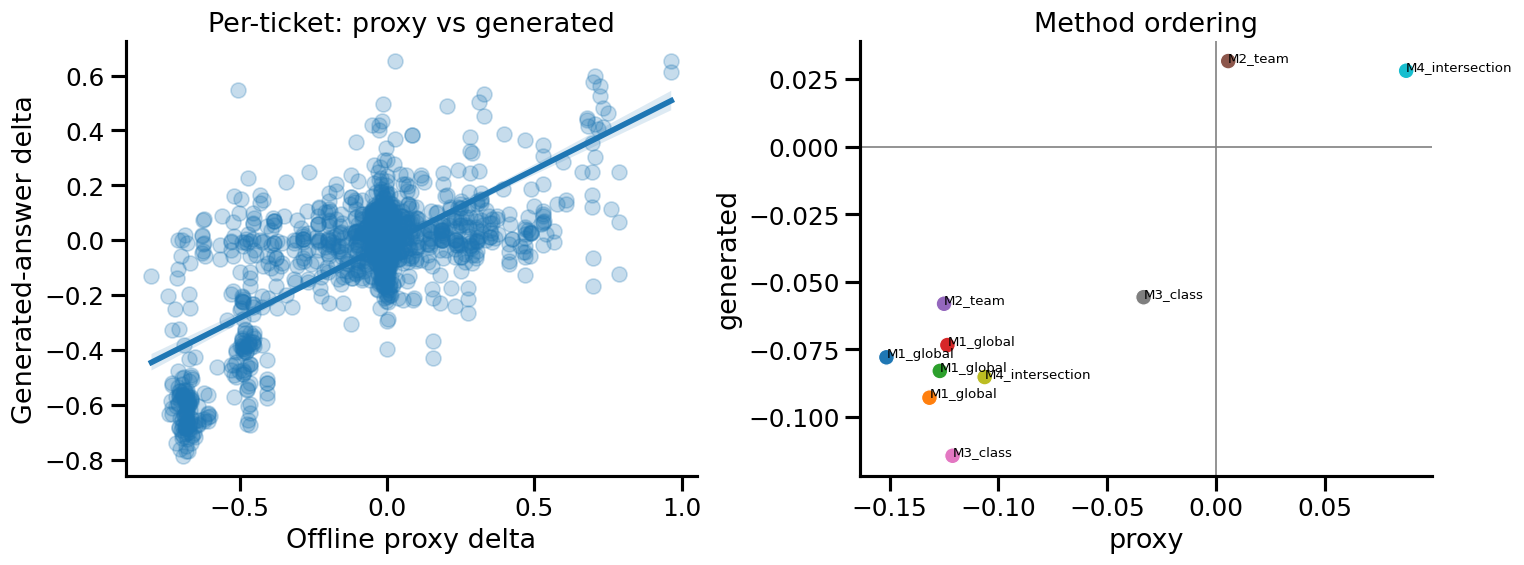

In [17]:
report = L.load_proxy_report(); tickets = L.load_proxy_per_ticket()
display(pd.json_normalize(report["decision"]))
changed = tickets[tickets["top1_changed"].astype(bool)]
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
sns.regplot(data=changed, x="minilm_d_proxy_top1", y="delta_cosine", scatter_kws={"alpha": .25}, ax=axes[0])
axes[0].set(title="Per-ticket: proxy vs generated", xlabel="Offline proxy delta", ylabel="Generated-answer delta")
method = changed.groupby("run", as_index=False).agg(generated=("delta_cosine", "mean"), proxy=("minilm_d_proxy_top1", "mean"))
sns.scatterplot(data=method, x="proxy", y="generated", hue="run", s=90, ax=axes[1], legend=False)
for _, row in method.iterrows():
    axes[1].annotate(row["run"].split("_dev")[0], (row["proxy"], row["generated"]), fontsize=8)
axes[1].axhline(0, color="gray", lw=1); axes[1].axvline(0, color="gray", lw=1); axes[1].set(title="Method ordering")
plt.tight_layout(); L.savefig("02_proxy_validity", run_ids=[]); plt.show()

**Reading.** The proxy orders *configurations* almost perfectly (method-order rank correlation 1.0) but
predicts individual tickets only weakly (rank correlation about 0.45). This is the paper's
methodological boundary: the proxy is a valid cheap tool for choosing which configurations deserve
a paid generation run, and an invalid label for per-ticket decisions. Later we show a concrete
sign flip (hybrid_rrf looks positive offline but is negative once generated), which is why every
headline number in this paper comes from generation.

### Did any run produce spurious deltas from duplicate generation?

**What we do.** When the feedback ranking leaves the generated context unchanged, the two prompts are identical. We audit legacy runs for such tickets and force their delta to zero in a corrected diagnostic.

**Artifact.** `results/identical_prompt_audit.csv`

**Caveat.** Corrects generation noise only; stored artifacts are unchanged.

*What this cell does.* Display, per run, how many tickets had identical ordered context and how the corrected mean shifts.

In [18]:
audit = L.load_identical_prompt_audit()
display(audit[["run", "n_identical_prompts", "pct_identical_prompts", "raw_mean_delta_cosine", "corrected_mean_delta_cosine", "correction"]].round(4))

,run,n_identical_prompts,pct_identical_prompts,raw_mean_delta_cosine,corrected_mean_delta_cosine,correction
0,M1_global_dev_blind_continuous,51,0.1599,-0.0319,-0.0334,-0.0015
1,M1_global_dev_conditioned_binary,113,0.3542,-0.0286,-0.0276,0.0010
2,M1_global_dev_conditioned_continuous,41,0.1285,-0.0356,-0.0345,0.0011
3,M2_team_dev_conditioned_continuous,7,0.0219,0.0194,0.0179,-0.0015
4,M3_class_dev_conditioned_continuous,60,0.1881,-0.0250,-0.0229,0.0020
5,M4_intersection_dev_conditioned_continuous,39,0.1223,0.0219,0.0209,-0.0010
6,baseline_dev_conditioned_continuous,319,1.0000,0.0000,0.0000,0.0000


**Reading.** Between 2% and 35% of legacy tickets had identical ordered contexts (except baselines,
which are identical by construction). Correcting them changes the means by less than 0.002, so the
qualitative findings are unaffected; the correction is reported for transparency, and future runs
generate once when the prompts match.

## Conclusion — protocol and validity

The feedback signal is well-behaved under the resolution-informed protocol and weaker but
informative under the ticket-only protocol. The offline proxy is valid for configuration selection
and invalid for tickets. These three results frame everything that follows: we use the proxy to
choose configurations, generate to report results, and always report both protocols.